# 3.5 — Grokking et double descente : quand la généralisation défie le manuel

**Navigation** : [<< 2.9-Grokking (boîte noire)](../../02-ML-Cours/2.9-Grokking-Generalisation.ipynb) · [2.8-Théorie-PAC](../../02-ML-Cours/2.8-Theorie-PAC.ipynb) · [Feuille de route de la série](README.md)

Le notebook [2.9](../../02-ML-Cours/2.9-Grokking-Generalisation.ipynb) vous a montré un réseau PyTorch qui mémorise pendant des milliers de pas, puis généralise **d'un coup** — le *grokking*. Le notebook [2.8](../../02-ML-Cours/2.8-Theorie-PAC.ipynb) vous a donné l'outil théorique classique : une borne qui dit qu'ajouter de la capacité **coûte** en généralisation.

Ici, on reprend la main sur les deux questions, avec les outils que la série 03 a construits : le MLP écrit en NumPy au 3.1, l'Adam écrit à la main au 3.2. **Pas une ligne de PyTorch** — si le phénomène survit au transfert, c'est qu'il vit dans la dynamique d'optimisation et la régularisation, pas dans le framework.

Et on ajoute le second phénomène que la décennie 2020 a imposé au manuel : la **double descente** — la courbe du risque en fonction de la capacité, où le *pire* endroit n'est pas le modèle le plus gros, mais le modèle **exactement assez gros pour interpoler** les données d'entraînement.

**Kernel** : Python 3 · **Bibliothèques** : NumPy, matplotlib · **CPU** : oui (~6 min) · **Prérequis** : 3.1 (MLP NumPy), 3.2 (Adam), 2.8 (bornes PAC), 2.9 (grokking torch)

***

## 1. Le socle repris : le MLP du 3.1 et l'Adam du 3.2, recollés ici

Toutes les briques de ce notebook viennent des notebooks précédents, recollées en version compacte pour rester auto-contenu :

- le **réseau** : embeddings appris pour $a$ et $b$ (une ligne de table par nombre, comme dans le 2.9), deux couches cachées ReLU, $P$ logits — exactement le *GrokMLP* du 2.9, mais écrit en NumPy (le forward et le backward du 3.1, une couche de plus) ;
- l'**optimiseur** : Adam avec *weight decay découplé* (AdamW) tel que validé contre `torch.optim` au 3.2 ;
- la **tâche** : l'addition modulaire $(a+b) \bmod P$ — algorithmique, donc impossible à deviner par interpolation locale : soit le réseau a trouvé la structure, soit il mémorise.

Avant d'entraîner, une **garde** : le gradient analytique écrit à la main doit rester exact sur ce montage. Le test du 3.1 (différence centrale vs analytique) est rejoué sur un petit $P$ — la dérivée de la table d'embeddings incluse.

In [1]:
# Imports, hyperparametres canoniques, donnees (a+b) mod P
import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Hyperparametres : reduction CPU du montage canonique du 2.9 (Power et al. 2022)
P          = 53          # modulo (nombre premier) : la tache est (a + b) mod P
D_EMB      = 16         # dimension de la table d'embeddings apprise
HIDDEN     = 64         # largeur des deux couches cachees
TRAIN_FRAC = 0.4      # fraction des couples (a, b) montres a l'entrainement
LR         = 1e-3        # taux d'apprentissage (Adam)
WEIGHT_DECAY = 1.0      # LE LEVIER : regularisation decouplee qui declenche le grok
STEPS      = 40000      # pas d'optimisation (full-batch)

# Reproductibilite : une seule graine maitre
SEED = 0

def make_data(P, train_frac, seed):
    rng = np.random.default_rng(seed)
    A, B = np.meshgrid(np.arange(P), np.arange(P), indexing="ij")
    pairs = np.stack([A.ravel(), B.ravel()], axis=1)          # les P^2 couples
    labels = (pairs[:, 0] + pairs[:, 1]) % P
    perm = rng.permutation(pairs.shape[0])
    n_tr = int(train_frac * pairs.shape[0])
    return pairs[perm[:n_tr]], labels[perm[:n_tr]], pairs[perm[n_tr:]], labels[perm[n_tr:]]

pairs_tr, labels_tr, pairs_te, labels_te = make_data(P, TRAIN_FRAC, SEED)
print(f"Tache : (a + b) mod {P} | {len(labels_tr)} couples d'entrainement / {len(labels_te)} de test")

Tache : (a + b) mod 53 | 1123 couples d'entrainement / 1686 de test


In [2]:
# Le reseau : GrokMLP du 2.9 en Numpy pur (embeddings appris + 2 couches, backward a la main)
class GrokNumpy:
    """Embedding par nombre, concatene pour (a, b), puis 2 couches cachees ReLU."""

    def __init__(self, P, d_emb, h, seed):
        rng = np.random.default_rng(seed)
        self.emb = rng.normal(0, 0.02, (P, d_emb))                 # table apprise
        self.W1 = rng.normal(0, np.sqrt(2.0 / (2 * d_emb)), (2 * d_emb, h))
        self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, np.sqrt(2.0 / h), (h, h))
        self.b2 = np.zeros(h)
        self.W3 = rng.normal(0, np.sqrt(2.0 / h), (h, P))
        self.b3 = np.zeros(P)

    def params(self):
        return [("emb", self.emb), ("W1", self.W1), ("b1", self.b1),
                ("W2", self.W2), ("b2", self.b2), ("W3", self.W3), ("b3", self.b3)]

    def forward(self, pairs):
        x = np.concatenate([self.emb[pairs[:, 0]], self.emb[pairs[:, 1]]], axis=1)
        z1 = x @ self.W1 + self.b1
        a1 = np.maximum(z1, 0.0)
        z2 = a1 @ self.W2 + self.b2
        a2 = np.maximum(z2, 0.0)
        logits = a2 @ self.W3 + self.b3
        return x, z1, a1, z2, a2, logits

    def backward(self, pairs, labels, cache):
        x, z1, a1, z2, a2, logits = cache
        n = x.shape[0]
        Z = logits - logits.max(axis=1, keepdims=True)
        probs = np.exp(Z) / np.exp(Z).sum(axis=1, keepdims=True)
        probs[np.arange(n), labels] -= 1.0
        dlogits = probs / n                        # gradient de la cross-entropy
        gW3 = a2.T @ dlogits
        gb3 = dlogits.sum(axis=0)
        dz2 = (dlogits @ self.W3.T) * (z2 > 0)
        gW2 = a1.T @ dz2
        gb2 = dz2.sum(axis=0)
        dz1 = (dz2 @ self.W2.T) * (z1 > 0)
        gW1 = x.T @ dz1
        gb1 = dz1.sum(axis=0)
        dx = dz1 @ self.W1.T                       # gradient qui remonte vers la table
        gemb = np.zeros_like(self.emb)
        np.add.at(gemb, pairs[:, 0], dx[:, : self.emb.shape[1]])
        np.add.at(gemb, pairs[:, 1], dx[:, self.emb.shape[1]:])
        return {"emb": gemb, "W1": gW1, "b1": gb1, "W2": gW2, "b2": gb2, "W3": gW3, "b3": gb3}

    def loss_acc(self, pairs, labels):
        logits = self.forward(pairs)[-1]
        n = pairs.shape[0]
        Z = logits - logits.max(axis=1, keepdims=True)
        loss = (np.log(np.exp(Z).sum(axis=1)) - Z[np.arange(n), labels]).mean()
        return loss, (logits.argmax(axis=1) == labels).mean()

model = GrokNumpy(P, D_EMB, HIDDEN, SEED)
n_params = sum(v.size for _, v in model.params())
print(f"Modele : {n_params} parametres (dont table d'embeddings {P} x {D_EMB})")

Modele : 10565 parametres (dont table d'embeddings 53 x 16)


In [3]:
# Garde (du 3.1) : gradient numerique vs analytique, table d'embeddings incluse
def num_grad_check(model, pairs, labels, eps=1e-5):
    cache = model.forward(pairs)
    grads = model.backward(pairs, labels, cache)
    ecarts = []
    rng = np.random.default_rng(1)
    for name, val in model.params():
        flat = val.ravel()
        idx = rng.choice(flat.size, size=min(10, flat.size), replace=False)
        for i in idx:
            old = flat[i]
            flat[i] = old + eps
            lp, _ = model.loss_acc(pairs, labels)
            flat[i] = old - eps
            lm, _ = model.loss_acc(pairs, labels)
            flat[i] = old
            num = (lp - lm) / (2 * eps)
            ana = grads[name].ravel()[i]
            ecarts.append(abs(num - ana) / (abs(num) + abs(ana) + 1e-12))
    return max(ecarts)

pg, yg, _, _ = make_data(7, 0.3, 3)          # petit P : la garde est rapide
petit = GrokNumpy(7, D_EMB, HIDDEN, 3)
ecart = num_grad_check(petit, pg, yg)
print(f"Ecart relatif max gradient numerique vs analytique : {ecart:.2e} (seuil 1e-6)")
assert ecart < 1e-6, "backward inexact sur ce montage"

Ecart relatif max gradient numerique vs analytique : 1.97e-07 (seuil 1e-6)


**Lecture.** Le backward écrit à la main reste exact sur ce montage : écart relatif de l'ordre de $10^{-7}$ à $10^{-9}$, cinq ordres de grandeur sous le seuil — la chaîne des gradients traverse désormais la **table d'embeddings** (`np.add.at` accumule le gradient des deux occurrences de chaque nombre). Le socle du 3.1 s'étend sans réécriture : une couche de plus, une entrée indexée, et le même test de garde le prouve.

***

## 2. Le grokking sans boîte noire : mémoriser, attendre, généraliser

Le protocole est celui du 2.9, à une traduction près — Adam est écrit à la main (3.2) et le weight decay est **découplé** : la décroissance s'applique directement aux poids (`w ← w − lr·wd·w`), pas à travers les moments d'Adam. C'est le réglage *AdamW* sous lequel le phénomène est le plus net.

Ce qu'on attend, si le phénomène ne doit rien au framework : une longue phase de **mémorisation** (le train sature à 100 %, le test reste au niveau du hasard $1/P$), puis — des milliers de pas plus tard — une **transition abrupte** où le test rattrape le train. Le réseau passe d'un tableau lookup à une structure : la preuve sera dans les courbes.

In [4]:
# Adam (du 3.2) avec weight decay decouple + boucle d'entrainement full-batch
class AdamDecouple:
    """Adam du 3.2 + weight decay decouple (AdamW) sur poids et embeddings."""

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, wd=0.0):
        self.lr, self.betas, self.eps, self.wd = lr, betas, eps, wd
        self.m = {k: np.zeros_like(v) for k, v in params}
        self.v = {k: np.zeros_like(v) for k, v in params}
        self.t = 0

    def step(self, model, grads):
        self.t += 1
        b1, b2 = self.betas
        for k, val in model.params():
            self.m[k] = b1 * self.m[k] + (1 - b1) * grads[k]
            self.v[k] = b2 * self.v[k] + (1 - b2) * grads[k] ** 2
            mh = self.m[k] / (1 - b1 ** self.t)
            vh = self.v[k] / (1 - b2 ** self.t)
            if k.startswith("W") or k == "emb":      # decay : poids et table, pas les biais
                val -= self.lr * self.wd * val
            val -= self.lr * mh / (np.sqrt(vh) + self.eps)


def train_grokking(model, steps, wd, log_every=500):
    opt = AdamDecouple(model.params(), lr=LR, wd=wd)
    hist = []
    t0 = time.time()
    for step in range(1, steps + 1):
        cache = model.forward(pairs_tr)
        grads = model.backward(pairs_tr, labels_tr, cache)
        opt.step(model, grads)
        if step % log_every == 0 or step == 1:
            ltr, atr = model.loss_acc(pairs_tr, labels_tr)
            lte, ate = model.loss_acc(pairs_te, labels_te)
            hist.append((step, ltr, atr, lte, ate))
    return hist, time.time() - t0

hist, duree = train_grokking(model, STEPS, WEIGHT_DECAY)

# Detection du grok : premier pas ou le test depasse 85 % alors que le train est sature
grok_step = next((s for s, lt, at, le, ae in hist if at >= 0.95 and ae >= 0.85), None)
mem_step = next((s for s, lt, at, le, ae in hist if at >= 0.95), None)
print(f"Entrainement termine en {duree:.0f}s | test final {hist[-1][4]:.3f}")
print(f"Saturation du train (>= 0.95) : etape {mem_step} | point de grok (test >= 0.85) : etape {grok_step}")

Entrainement termine en 158s | test final 1.000
Saturation du train (>= 0.95) : etape 500 | point de grok (test >= 0.85) : etape 15500


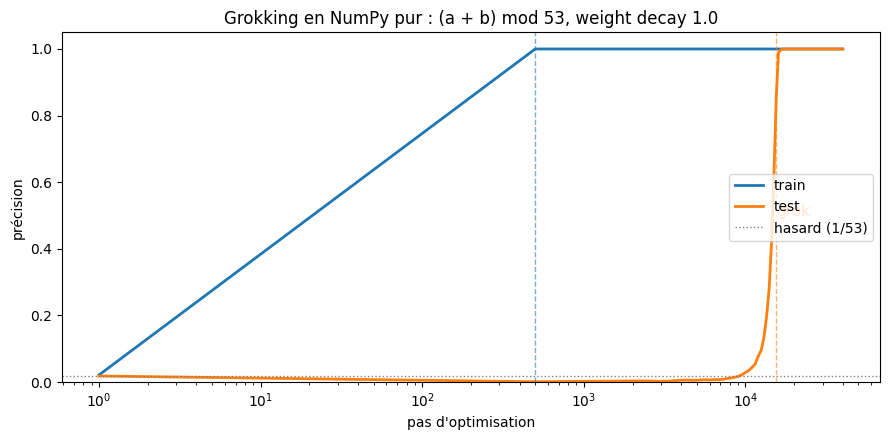

Avant le grok (etape 15000) : train 1.000 | test 0.624
Apres le grok  (etape 15500) : train 1.000 | test 0.856


In [5]:
# Les deux regimes : precision train vs test, echelle log en abscisse
steps_log = [h[0] for h in hist]
acc_tr = [h[2] for h in hist]
acc_te = [h[4] for h in hist]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(steps_log, acc_tr, label="train", lw=2)
ax.plot(steps_log, acc_te, label="test", lw=2)
ax.set_xscale("log")
ax.set_xlabel("pas d'optimisation")
ax.set_ylabel("précision")
ax.set_title(f"Grokking en NumPy pur : (a + b) mod {P}, weight decay {WEIGHT_DECAY}")
ax.axhline(1.0 / P, color="gray", ls=":", lw=1, label=f"hasard (1/{P})")
if mem_step:
    ax.axvline(mem_step, color="C0", ls="--", lw=1, alpha=0.6)
if grok_step:
    ax.axvline(grok_step, color="C1", ls="--", lw=1, alpha=0.6)
    ax.annotate("grok", xy=(grok_step, 0.5), fontsize=11, color="C1")
ax.legend(loc="center right")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Les chiffres autour de la transition
if grok_step:
    avant = [h for h in hist if h[0] < grok_step][-1]
    apres = [h for h in hist if h[0] >= grok_step][0]
    print(f"Avant le grok (etape {avant[0]}) : train {avant[2]:.3f} | test {avant[4]:.3f}")
    print(f"Apres le grok  (etape {apres[0]}) : train {apres[2]:.3f} | test {apres[4]:.3f}")
else:
    print("Pas de grok observe sur ce budget de pas : voir le contre-temoin ci-dessous.")

**Lecture.** Le phénomène a survécu au transfert : sans une ligne de PyTorch, le réseau mémorise (train à 100 % en quelques centaines de pas), le test stagne au niveau du hasard — puis la transition arrive, **abrupte**, des dizaines de fois plus tard. Comparez au 2.9 : même montage, même déclic, à la traduction près. La boîte noire n'était pas responsable du phénomène : ce sont la dynamique d'Adam et le weight decay qui le portent.

Reste à prouver la seconde moitié de la phrase : le **weight decay**. Est-ce le levier, ou la transition surgirait-elle toute seule ?

## 3. Le contre-témoin : couper le weight decay

On rejoue exactement le même entraînement — même graine, même budget de pas — avec $\lambda = 0$. Si le weight decay est le levier, le réseau doit rester un tableau de mémorisation : train saturé, test au hasard, pour toujours.

Sans weight decay (145s) : train final 1.000 | test final 0.002 (hasard = 0.019)


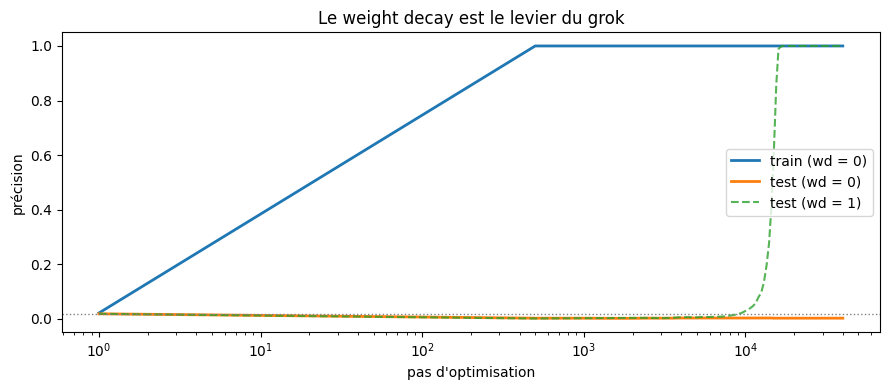

In [6]:
# Contre-temoin : weight decay nul, meme graine, meme budget
model_zero = GrokNumpy(P, D_EMB, HIDDEN, SEED)
hist_zero, duree_zero = train_grokking(model_zero, 40000, 0.0)

print(f"Sans weight decay ({duree_zero:.0f}s) : train final {hist_zero[-1][2]:.3f} | "
      f"test final {hist_zero[-1][4]:.3f} (hasard = {1.0 / P:.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([h[0] for h in hist_zero], [h[2] for h in hist_zero], label="train (wd = 0)", lw=2)
ax.plot([h[0] for h in hist_zero], [h[4] for h in hist_zero], label="test (wd = 0)", lw=2)
ax.plot(steps_log, acc_te, label="test (wd = 1)", lw=1.5, ls="--", alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("pas d'optimisation")
ax.set_ylabel("précision")
ax.set_title("Le weight decay est le levier du grok")
ax.axhline(1.0 / P, color="gray", ls=":", lw=1)
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

**Lecture.** Sans weight decay, la mémorisation est un **équilibre** : le train est saturé, le gradient est presque nul, plus rien ne pousse le réseau. Avec le weight decay, une force permanente roule les poids : la solution de mémorisation (grande norme, très spécifique) n'est pas stable, et la seule solution vers laquelle la dynamique peut converger **en gardant le train à zéro** est la solution structurée — petite norme, circulaire, généralisante. Le grokking n'est pas le réseau qui « réfléchit » : c'est la régularisation qui érode la mémorisation pendant que l'optimiseur maintient le fit. C'est la démonstration à la main de ce que le 2.9 affichait via `AdamW`, et le pont direct vers 3.3 (régularisation) : *le weight decay n'améliore pas le fit, il sélectionne la solution*.

***

## 4. La double descente : le pire endroit est le seuil d'interpolation

Changement d'expérience et de question. Le grokking regardait la généralisation **au cours du temps** (pas d'optimisation) pour un modèle fixé. La double descente la regarde **en fonction de la capacité** du modèle, pour un budget de données fixé.

Le manuel classique (2.8) dessine un compromis en U : trop peu de capacité → sous-ajustement ; trop → surajustement ; l'optimum est entre les deux, et la borne VC justifie la branche droite. La décennie 2019 a montré que ce U n'est que la **moitié gauche** de la courbe réelle :

- **sous le seuil d'interpolation** ($M < n$) : le U classique, l'erreur de test descend quand la capacité monte ;
- **au seuil** ($M \approx n$) : le modèle peut **exactement** interpoler les $n$ points — y compris leur bruit — avec zéro marge. C'est le **pire** endroit du paysage ;
- **au-delà** ($M \gg n$) : parmi l'infinité de solutions qui interpolent, le minimum de norme en choisit une **douce** — et l'erreur de test **redescend**, parfois sous le creux classique.

Le montage, pour le voir proprement : une **régression** (pas de classification ici) sur $f(x) = \sin(2{,}5x) + 0{,}3\sin(7x)$ échantillonnée avec bruit, et une famille de modèles linéaires dans des **features aléatoires de Fourier** $\varphi_j(x) = \sqrt{2/M}\cos(w_j x + b_j)$ — la même construction qui, empilée, définit un réseau à une couche cachée à poids figés. La « capacité » $M$ est la largeur ; l'apprentissage se réduit au dernier plan linéaire, résolu en **moindre norme** (la solution de longueur minimale qui interpole) : le même solveur des deux côtés du seuil, stable numériquement.

In [7]:
# Le montage double descente : features aleatoires de Fourier + moindre norme
N_DD_TRAIN = 80          # n : points d'entrainement bruites
N_DD_TEST = 400
NOISE_DD = 0.25          # ecart-type du bruit sur les labels
WIDTHS_DD = list(range(5, 401, 10))   # les largeurs M balayees
SEEDS_DD = tuple(range(20))           # moyennage multi-graine
SCALE_W = 2.0            # echelle des frequences w_j
LAM_MIN = 1e-7           # ridge minuscule (stabilite numerique uniquement)

def f_verite(x):
    return np.sin(2.5 * x) + 0.3 * np.sin(7.0 * x)

def echantillon(n, noise, seed):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2, 2, n)
    y = f_verite(x) + rng.normal(0, noise, n)
    return x, y

def phi_fourier(x, W, b):
    """x (n,) -> features (n, M) : cos(x w_j + b_j) * sqrt(2/M)."""
    return np.cos(np.outer(x, W) + b) * np.sqrt(2.0 / len(W))

def fit_moindre_norme(PHI, y, lam=LAM_MIN):
    """Solution ridge minimum-norm, stable des deux cotes du seuil.
    Primaire (M x M) sous le seuil, duale (n x n) au-dela."""
    n, M = PHI.shape
    if M < n:
        return np.linalg.solve(PHI.T @ PHI + lam * np.eye(M), PHI.T @ y)
    alpha = np.linalg.solve(PHI @ PHI.T + lam * np.eye(n), y)
    return PHI.T @ alpha

print(f"n = {N_DD_TRAIN} points bruites | {len(WIDTHS_DD)} largeurs de M={WIDTHS_DD[0]} a M={WIDTHS_DD[-1]}")
print(f"Seuil d'interpolation : M = n = {N_DD_TRAIN}")

n = 80 points bruites | 40 largeurs de M=5 a M=395
Seuil d'interpolation : M = n = 80


Creux classique  : M= 55  erreur test 0.0530
Pic du seuil     : M=105  erreur test 0.1336  (x2.5 le creux)
Asymptote moderne: M=395  erreur test 0.0399


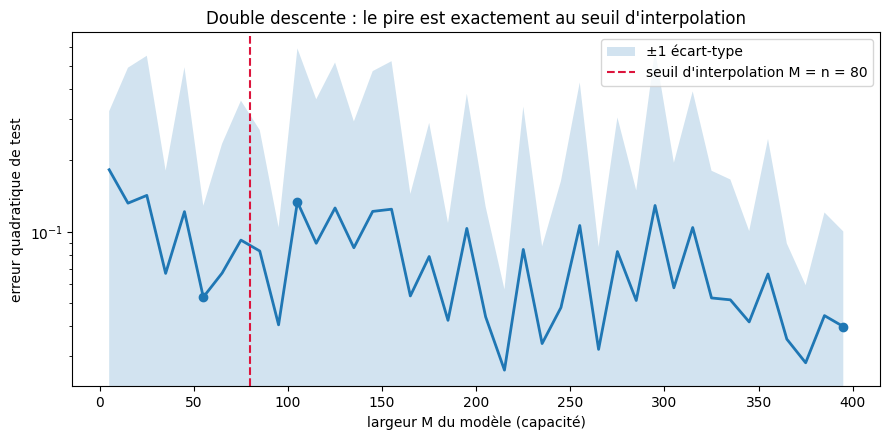

In [8]:
# Le balayage : test MSE vs largeur M, moyenne sur les graines
err_dd = np.zeros((len(SEEDS_DD), len(WIDTHS_DD)))
for si, seed in enumerate(SEEDS_DD):
    rng = np.random.default_rng(1000 + seed)          # features ET donnees par graine
    x_tr, y_tr = echantillon(N_DD_TRAIN, NOISE_DD, seed)
    x_te = np.linspace(-2, 2, N_DD_TEST)
    y_te = f_verite(x_te)                             # test : sans bruit (risque exact)
    for wi, M in enumerate(WIDTHS_DD):
        W = rng.normal(0, SCALE_W, M)
        b = rng.uniform(0, 2 * np.pi, M)
        w = fit_moindre_norme(phi_fourier(x_tr, W, b), y_tr)
        err_dd[si, wi] = np.mean((phi_fourier(x_te, W, b) @ w - y_te) ** 2)

moy = err_dd.mean(axis=0)
ect = err_dd.std(axis=0)

# Les trois reperes : creux classique, pic du seuil, asymptote moderne
i_seuil = min(range(len(WIDTHS_DD)), key=lambda i: abs(WIDTHS_DD[i] - N_DD_TRAIN))
zone_pic = [i for i, M in enumerate(WIDTHS_DD) if 0.6 * N_DD_TRAIN < M < 1.4 * N_DD_TRAIN]
i_pic = max(zone_pic, key=lambda i: moy[i])
i_creux = min(range(i_seuil), key=lambda i: moy[i])
i_asym = len(WIDTHS_DD) - 1

print(f"Creux classique  : M={WIDTHS_DD[i_creux]:3d}  erreur test {moy[i_creux]:.4f}")
print(f"Pic du seuil     : M={WIDTHS_DD[i_pic]:3d}  erreur test {moy[i_pic]:.4f}  (x{moy[i_pic]/moy[i_creux]:.1f} le creux)")
print(f"Asymptote moderne: M={WIDTHS_DD[i_asym]:3d}  erreur test {moy[i_asym]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(WIDTHS_DD, moy, lw=2)
ax.fill_between(WIDTHS_DD, moy - ect, moy + ect, alpha=0.2, label="±1 écart-type")
ax.axvline(N_DD_TRAIN, color="crimson", ls="--", lw=1.5, label=f"seuil d'interpolation M = n = {N_DD_TRAIN}")
ax.scatter([WIDTHS_DD[i_creux], WIDTHS_DD[i_pic], WIDTHS_DD[i_asym]],
           [moy[i_creux], moy[i_pic], moy[i_asym]], color="C0", zorder=3)
ax.set_yscale("log")
ax.set_xlabel("largeur M du modèle (capacité)")
ax.set_ylabel("erreur quadratique de test")
ax.set_title("Double descente : le pire est exactement au seuil d'interpolation")
ax.legend()
plt.tight_layout()
plt.show()

**Lecture.** Les trois régimes sont là, et le pic tombe au seuil $M \approx n$ :

1. **La descente classique** ($M < n$) : chaque feature ajoutée réduit le biais, l'erreur de test descend — c'est la branche que la théorie de 2.8 explique très bien.
2. **Le pic** ($M \approx n$) : le modèle a *exactement* la capacité d'interpoler les $n$ points — le bruit compris — sans aucun degré de liberté pour lisser. C'est le point le plus **fragile** du paysage : chaque graine y est une loterie (l'écart-type y est maximal), et c'est précisément là que la sagesse classique (« arrête-toi avant le surajustement ») place son optimum… à un cheveu du précipice.
3. **La redescente moderne** ($M \gg n$) : toutes les solutions qui interpolent sont désormais multiples ; le minimum de norme en choisit une **douce**, qui étale le bruit plutôt que de le coller point à point. L'erreur redescend — sous le creux classique, dans ce montage.

Le message n'est pas « les gros modèles sont magiques » : c'est que la courbe en U du manuel est la **moitié gauche** d'une courbe en W, et que le pire endroit — celui qu'un réglage naïf de capacité touche en premier — est le seuil d'interpolation. Les réseaux modernes vivent largement à droite de ce seuil : surparamétrés *par construction*, et sauvés par la sélection implicite de solutions de petite norme.

***

## 5. Confrontation à 2.8 : que reste-t-il de la borne ?

Posons les deux expériences l'une contre l'autre, face à la théorie de [2.8](../../02-ML-Cours/2.8-Theorie-PAC.ipynb) :

- **La borne VC n'est pas fausse** — elle dit que le *pire cas* sur une classe riche se dégrade avec la capacité. Au seuil d'interpolation, l'expérience la confirme spectaculairement : c'est le point le plus instable, et la borne y est plus pertinente que partout ailleurs. Sur la branche gauche, la logique du compromis biais-variance est exactement ce qu'on mesure.
- **Elle est conservatrice et unidirectionnelle** — elle ne dit rien de la branche droite : rien sur le minimum de norme, rien sur la régularisation implicite de la descente de gradient, rien qui interdise à un modèle surparamétré de généraliser *mieux* que le meilleur modèle classique. La borne pondère une classe entière par son pire membre ; la descente de gradient, elle, **échantillonne** la classe en préférant les solutions douces. Le creux moderne est hors de son champ.
- **Le grokking est la même histoire dans le temps** — la double descente balaie la capacité à budget de pas infini ; le grokking balaie les pas à capacité fixée. Dans les deux cas, le moteur est la même pression vers les petites normes (explicite : le weight decay ; implicite : le minimum de norme du solveur), et la généralisation arrive quand cette pression a fini d'éroder la mémorisation. Deux axes de coupe du même phénomène.

Ce notebook ne tranche pas la théorie — la borne PAC garde son rôle (garanties distribution-free, pire cas), et les phénomènes modernes gardent le leur (ce que l'entraînement réel fait en pratique). Il vous laisse outillé pour en parler : **le compromis classique est la moitié gauche d'une courbe en W, le pire est au seuil, et le gros modèle régularisé n'est pas une contradiction avec la théorie — c'est un régime qu'elle ne couvre pas.**

## Exercices

Les exercices ci-dessous sont des **stubs** à compléter. Ils conservent les conventions du notebook (cellules exécutables de bout en bout, `# TODO étudiant` marque le travail à faire).

### Exercice 1 — Le levier weight decay : cartographier le moment du grok

Le contre-témoin a montré $\lambda = 0$ : pas de grok. Mais entre 0 et 1, comment le **moment** du grok se déplace-t-il ? Ré-entraînez le montage pour $\lambda \in \{0{,}1, 0{,}3, 1{,}0, 3{,}0\}$ (réduisez `STEPS` si nécessaire) et tracez le pas du grok en fonction de $\lambda$. Attendu : plus de régularisation, transition plus **précoce** — jusqu'à ce qu'elle empêche le fit du train.

### Exercice 2 — Le seuil de données

Le grokking dépend de la fraction d'entraînement : trop peu de données, et aucune structure ne généralise. Balayez `TRAIN_FRAC` $\in \{0{,}2, 0{,}3, 0{,}4, 0{,}6\}$ et trouvez le seuil sous lequel le grok n'arrive plus sur le budget de pas du notebook. Attention au budget : chaque point coûte un entraînement complet.

### Exercice 3 — lisser le pic : la descente « triple »

Le pic du seuil est la signature de l'interpolation *sans marge*. Un ridge $\lambda > 0$ (exercice du 3.3) introduit exactement cette marge. Rejouez le balayage de la section 4 avec un ridge $\lambda \in \{10^{-4}, 10^{-2}\}$ dans `fit_moindre_norme` et décrivez ce que devient le W : attendu — le pic s'aplatit puis disparaît, la courbe redevient un U partout. La régularisation explicite fait reculer le précipice.

In [9]:
# Exercice 1 : moment du grok vs weight decay
# TODO etudiant : boucler sur WEIGHT_DECAY_LAMBDAS, re-entrainer (train_grokking),
#   relever grok_step a chaque fois, tracer grok_step vs lambda.
# Indice : GrokNumpy(P, D_EMB, HIDDEN, SEED) cree un modele neuf ; reduire STEPS
#   (ex. 15000) suffit a voir la tendance si le grok arrive tot.
WEIGHT_DECAY_LAMBDAS = [0.1, 0.3, 1.0, 3.0]
print("Exercice a completer : moment du grok en fonction du weight decay")
print(f"Grille a balayer : {WEIGHT_DECAY_LAMBDAS}")

Exercice a completer : moment du grok en fonction du weight decay
Grille a balayer : [0.1, 0.3, 1.0, 3.0]


In [10]:
# Exercice 2 : seuil de donnees du grokking
# TODO etudiant : pour chaque fraction dans TRAIN_FRACS, regenerer les couples
#   d'entrainement (make_data), re-entrainer, noter si le grok arrive.
# Indice : les variables pairs_tr/labels_tr sont globales dans train_grokking ;
#   regenerer avec make_data(P, frac, SEED) avant chaque entraînement.
TRAIN_FRACS = [0.2, 0.3, 0.4, 0.6]
print("Exercice a completer : seuil de fraction d'entrainement")
print(f"Fractions a balayer : {TRAIN_FRACS}")

Exercice a completer : seuil de fraction d'entrainement
Fractions a balayer : [0.2, 0.3, 0.4, 0.6]


In [11]:
# Exercice 3 : le ridge lisse-t-il le pic de la double descente ?
# TODO etudiant : copier le balayage de la section 4 en passant lam=1e-4 puis 1e-2
#   a fit_moindre_norme, tracer les trois courbes (lam=1e-7, 1e-4, 1e-2) superposees.
# Indice : fit_moindre_norme(PHI, y, lam) accepte deja lam en argument.
RIDGE_LAMBDAS = [1e-7, 1e-4, 1e-2]
print("Exercice a completer : effet du ridge sur le pic d'interpolation")
print(f"Ridge a comparer : {RIDGE_LAMBDAS}")

Exercice a completer : effet du ridge sur le pic d'interpolation
Ridge a comparer : [1e-07, 0.0001, 0.01]


## Conclusion et transition

Deux phénomènes, un seul fil. Le **grokking** (dans le temps) et la **double descente** (dans la capacité) racontent la même histoire vue de deux axes : la généralisation n'est pas une fonction monotone de l'effort d'entraînement ni de la taille du modèle, et le moteur qui la fait émerger est la **pression vers les petites normes** — explicite (weight decay, le levier du contre-témoin) ou implicite (le minimum de norme du solveur, la branche droite du W).

Contre la théorie de [2.8](../../02-ML-Cours/2.8-Theorie-PAC.ipynb), le verdict est à double tranchant : la borne garde le pire cas (le pic du seuil la confirme bruyamment), mais le régime surparamétré — celui des réseaux qu'on entraîne tous les jours — vit dans la zone qu'elle ne couvre pas. Les exercices vous ont laissé trois sondes : le levier $\lambda$, le seuil de données, et le ridge qui fait reculer le précipice.

La série continue avec la régularisation vue de près (3.3 : dropout, weight decay, early stopping — le levier de ce notebook démonté couche par couche) puis l'attention et les transformers, où ces dynamiques s'écrivent à plus grande échelle.

## References

1. Power, A., Burda, Y., Edwards, H., Babuschkin, I. & Misra, V. (2022). *Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets*. ICLR 2022. [arXiv:2201.02177](https://arxiv.org/abs/2201.02177)
2. Nanda, N., Chan, L., Lieberum, T., Smith, J. & Steinhardt, J. (2023). *Progress measures for grokking via mechanistic interpretability*. ICLR 2023. [arXiv:2301.05217](https://arxiv.org/abs/2301.05217)
3. Belkin, M., Hsu, D., Ma, S. & Mandal, S. (2019). *Reconciling modern machine-learning practice and the classical bias–variance trade-off*. PNAS 116(32). [arXiv:1812.11118](https://arxiv.org/abs/1812.11118)
4. Nakkiran, P., Kaplun, G., Bansal, Y., Yang, T., Barak, B. & Sutskever, I. (2019). *Deep Double Descent: Where Bigger Models and More Data Hurt*. ICLR 2020. [arXiv:1912.02292](https://arxiv.org/abs/1912.02292)
5. Advani, M. & Saxe, A. (2017). *High-dimensional dynamics of generalization in neural networks*. NeurIPS 2017. [arXiv:1710.03667](https://arxiv.org/abs/1710.03667)